# ODAPT

## 1. Transcriptomic Analysis + Drug Reversal Scoring

### a. Data set download

The project started by downloading the GEO dataset GSE83148, which contains transcriptomic expression data for 128 samples: 122 infected and 6 controls. After importing all necessary libraries for data manipulation, statistics, visualization, and cheminformatics, the raw expression data was loaded and inspected.

Setting the enviorment

In [ ]:
!pip install pandas numpy matplotlib seaborn GEOparse

In [ ]:
!pip install tqdm useful_rdkit_utils seaborn scikit-posthocs chembl_downloader chembl_webresource_client pubchempy

In [ ]:
!pip install cmapPy

In [ ]:
!pip install scikit-posthocs

In [ ]:
!pip install rdkit

In [ ]:
!pip install bioinfokit gseapy adjustText rpy2

In [ ]:
# R install
!apt-get install r-base

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.1-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [ ]:
!R -e "install.packages('BiocManager', repos='https://cran.r-project.org')"
!R -e "BiocManager::install('limma')"
!R -e "BiocManager::install('GEOquery')"
!R -e "BiocManager::install('edgeR')"


R version 4.5.1 (2025-06-13) -- "Great Square Root"
Copyright (C) 2025 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> install.packages('BiocManager', repos='https://cran.r-project.org')
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.r-project.org/src/contrib/BiocManager_1.30.26.tar.gz'
Content type 'application/x-gzip' length 594489 bytes (580 KB)
downloaded 580 KB

* i

In [ ]:
!R -e "BiocManager::install('clusterProfiler')"
!R -e "BiocManager::install('ReactomePA')"
!R -e "BiocManager::install('org.Hs.eg.db')"


R version 4.5.1 (2025-06-13) -- "Great Square Root"
Copyright (C) 2025 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> BiocManager::install('clusterProfiler')
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.21 (BiocManager 1.30.26), R 4.5.1 (2025-06-13)
Old packages

In [ ]:
# Data manipulation and numerical computing
import pandas as pd
import numpy as np
import os

# Statistics and data preprocessing
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.impute import SimpleImputer

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# GEO data parsing
import GEOparse
from cmapPy.pandasGEXpress.parse import parse

# RDKit for cheminformatics
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.Chem import FilterCatalog
from rdkit.Chem.FilterCatalog import FilterCatalogParams
from rdkit.Chem import AllChem
from rdkit.DataStructs import TanimotoSimilarity

# ChEMBL web resource client
from chembl_webresource_client.new_client import new_client


# R-Python
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr


In [ ]:
# Activate convertion
pandas2ri.activate()

#Import R package
limma = importr('limma')
ggplot2 = importr('ggplot2')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
gse = GEOparse.get_GEO(geo="GSE83148", destdir="./")

11-Sep-2025 01:29:16 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
11-Sep-2025 01:29:16 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
11-Sep-2025 01:29:16 INFO GEOparse - Parsing ./GSE83148_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE83148_family.soft.gz: 
11-Sep-2025 01:29:16 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
11-Sep-2025 01:29:16 DEBUG GEOparse - SERIES: GSE83148
DEBUG:GEOparse:SERIES: GSE83148
11-Sep-2025 01:29:16 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570
/usr/local/lib/python3.12/dist-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
11-Sep-2025 01:29:18 DEBUG GEOparse - SAMPLE: GSM2195416
DEBUG:GEOparse:SAMPLE: GSM2195416
11-Sep-2025 01:29:19 DEBUG GEOpars

In [ ]:
# Visualize in a data frame
df_gse = gse.pivot_samples('VALUE')
df_gse

name,GSM2195416,GSM2195417,GSM2195418,GSM2195419,GSM2195420,GSM2195421,GSM2195422,GSM2195423,GSM2195424,GSM2195425,...,GSM2195534,GSM2195535,GSM2195536,GSM2195537,GSM2291960,GSM2291961,GSM2291962,GSM2291963,GSM2291964,GSM2291965
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,7.87550,6.80810,7.01067,6.87384,6.91454,7.14768,7.05695,7.40349,7.33204,7.43099,...,6.43570,7.32376,7.25377,6.91295,6.37363,6.49795,6.43963,6.36531,6.41111,6.76942
1053_at,6.29315,5.79981,6.66245,5.83645,5.81384,6.11788,5.99030,5.88610,6.13099,6.12643,...,6.57556,5.89270,6.56900,6.02517,6.07680,6.05225,6.24640,5.96225,6.17774,6.13837
117_at,4.72855,4.83994,5.08763,5.03321,4.92007,4.51137,4.87317,4.71532,4.92108,4.67567,...,5.01273,5.06820,5.05112,5.33136,4.52563,4.41339,4.69457,4.39229,4.90550,4.48230
121_at,6.96665,6.67761,7.30685,7.64177,7.28214,6.85364,7.11758,7.19491,6.93070,7.14518,...,7.05218,8.31497,6.90509,7.23741,6.72771,6.92092,6.43475,6.69107,6.66813,6.67931
1255_g_at,1.85751,1.72451,2.09563,1.82042,1.89416,1.96510,1.98721,2.01883,2.19108,2.25712,...,2.21792,2.12660,1.82771,1.99025,1.65623,1.87992,1.89249,1.72565,1.69217,1.68314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AFFX-r2-Ec-bioC-5_at,8.02208,9.78277,9.96045,10.61390,9.03569,9.05317,9.37279,9.27172,9.45382,9.29574,...,10.17320,11.25930,9.82280,9.72706,9.69447,9.61688,9.74083,9.62794,9.73554,9.86623
AFFX-r2-Ec-bioD-3_at,10.52260,11.95700,11.63290,12.68420,11.48890,11.33360,11.56720,11.58910,11.72650,11.54470,...,12.34520,13.08950,12.45990,12.42100,12.04100,11.92310,11.98480,11.89110,12.02050,12.07160
AFFX-r2-Ec-bioD-5_at,9.52292,11.14590,10.45660,11.85640,10.42180,10.42260,10.62210,10.56370,10.71260,10.52320,...,11.43940,12.39110,11.60060,11.51200,11.29570,11.20720,11.24160,11.09040,11.24860,11.31790


### b. Gene Groupby

To consolidate probe-level expression data into gene-level, the annotation file for the microarray platform (GPL570) was used. Probes were grouped by their corresponding gene symbols, and their expression values were averaged. This step was crucial to reduce redundancy and ensure the analysis focused on biologically relevant gene-level signals.


In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/Project'
os.chdir(path)

In [ ]:
# Probe --> Gene
anot = pd.read_csv("GPL570-55999.txt", sep="\t", dtype=str, comment='#')

In [ ]:
anot

,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
0,1007_s_at,U48705,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...,U48705,discoidin domain receptor tyrosine kinase 1 //...,DDR1 /// MIR4640,780 /// 100616237,NM_001202521 /// NM_001202522 /// NM_001202523...,0001558 // regulation of cell growth // inferr...,0005576 // extracellular region // inferred fr...,0000166 // nucleotide binding // inferred from...
1,1053_at,M87338,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,M87338 /FEATURE= /DEFINITION=HUMA1SBU Human re...,M87338,"replication factor C (activator 1) 2, 40kDa",RFC2,5982,NM_001278791 /// NM_001278792 /// NM_001278793...,0000278 // mitotic cell cycle // traceable aut...,0005634 // nucleus // inferred from electronic...,0000166 // nucleotide binding // inferred from...
2,117_at,X51757,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,X51757 /FEATURE=cds /DEFINITION=HSP70B Human h...,X51757,heat shock 70kDa protein 6 (HSP70B'),HSPA6,3310,NM_002155,0000902 // cell morphogenesis // inferred from...,0005737 // cytoplasm // inferred from direct a...,0000166 // nucleotide binding // inferred from...
3,121_at,X69699,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,X69699 /FEATURE= /DEFINITION=HSPAX8A H.sapiens...,X69699,paired box 8,PAX8,7849,NM_003466 /// NM_013951 /// NM_013952 /// NM_0...,0001655 // urogenital system development // in...,0005634 // nucleus // inferred from direct ass...,0000979 // RNA polymerase II core promoter seq...
4,1255_g_at,L36861,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,L36861 /FEATURE=expanded_cds /DEFINITION=HUMGC...,L36861,guanylate cyclase activator 1A (retina),GUCA1A,2978,NM_000409 /// XM_006715073,0007165 // signal transduction // non-traceabl...,0001750 // photoreceptor outer segment // infe...,0005509 // calcium ion binding // inferred fro...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54670,AFFX-ThrX-5_at,NaN,--Control,Homo sapiens,"Oct 6, 2014",Control sequence,Affymetrix Proprietary Database,B. subtilis /GEN=thrC /DB_XREF=gb:X04603.1 /NO...,AFFX-ThrX-5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54671,AFFX-ThrX-M_at,NaN,--Control,Homo sapiens,"Oct 6, 2014",Control sequence,Affymetrix Proprietary Database,"B. subtilis /GEN=thrC, thrB /DB_XREF=gb:X04603...",AFFX-ThrX-M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54672,AFFX-TrpnX-3_at,NaN,--Control,Homo sapiens,"Oct 6, 2014",Control sequence,Affymetrix Proprietary Database,"B. subtilis /GEN=trpC, trpF /DB_XREF=gb:K01391...",AFFX-TrpnX-3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54673,AFFX-TrpnX-5_at,NaN,--Control,Homo sapiens,"Oct 6, 2014",Control sequence,Affymetrix Proprietary Database,"B. subtilis /GEN=trpE, trpD /DB_XREF=gb:K01391...",AFFX-TrpnX-5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
anot.columns = anot.columns.str.strip()

In [ ]:
df_gse.columns = df_gse.columns.str.strip()
# Drop Dulicates
if 'ID_REF\t' in df_gse.columns:
    df_gse = df_gse.drop(columns=['ID_REF\t'])

if 'ID_REF' in df_gse.columns:
    df_gse = df_gse.drop.duplicated(columns=['ID_REF'])

df_gse = df_gse.loc[:, ~df_gse.columns.duplicated()]

In [ ]:
anot_indexed = anot.set_index('ID')
df_gse_2 = df_gse.merge(anot_indexed[['Gene Symbol']], left_index=True, right_index=True, how='left')

In [ ]:
df_gse_2

,GSM2195416,GSM2195417,GSM2195418,GSM2195419,GSM2195420,GSM2195421,GSM2195422,GSM2195423,GSM2195424,GSM2195425,...,GSM2195535,GSM2195536,GSM2195537,GSM2291960,GSM2291961,GSM2291962,GSM2291963,GSM2291964,GSM2291965,Gene Symbol
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,7.87550,6.80810,7.01067,6.87384,6.91454,7.14768,7.05695,7.40349,7.33204,7.43099,...,7.32376,7.25377,6.91295,6.37363,6.49795,6.43963,6.36531,6.41111,6.76942,DDR1 /// MIR4640
1053_at,6.29315,5.79981,6.66245,5.83645,5.81384,6.11788,5.99030,5.88610,6.13099,6.12643,...,5.89270,6.56900,6.02517,6.07680,6.05225,6.24640,5.96225,6.17774,6.13837,RFC2
117_at,4.72855,4.83994,5.08763,5.03321,4.92007,4.51137,4.87317,4.71532,4.92108,4.67567,...,5.06820,5.05112,5.33136,4.52563,4.41339,4.69457,4.39229,4.90550,4.48230,HSPA6
121_at,6.96665,6.67761,7.30685,7.64177,7.28214,6.85364,7.11758,7.19491,6.93070,7.14518,...,8.31497,6.90509,7.23741,6.72771,6.92092,6.43475,6.69107,6.66813,6.67931,PAX8
1255_g_at,1.85751,1.72451,2.09563,1.82042,1.89416,1.96510,1.98721,2.01883,2.19108,2.25712,...,2.12660,1.82771,1.99025,1.65623,1.87992,1.89249,1.72565,1.69217,1.68314,GUCA1A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AFFX-r2-Ec-bioC-5_at,8.02208,9.78277,9.96045,10.61390,9.03569,9.05317,9.37279,9.27172,9.45382,9.29574,...,11.25930,9.82280,9.72706,9.69447,9.61688,9.74083,9.62794,9.73554,9.86623,NaN
AFFX-r2-Ec-bioD-3_at,10.52260,11.95700,11.63290,12.68420,11.48890,11.33360,11.56720,11.58910,11.72650,11.54470,...,13.08950,12.45990,12.42100,12.04100,11.92310,11.98480,11.89110,12.02050,12.07160,NaN
AFFX-r2-Ec-bioD-5_at,9.52292,11.14590,10.45660,11.85640,10.42180,10.42260,10.62210,10.56370,10.71260,10.52320,...,12.39110,11.60060,11.51200,11.29570,11.20720,11.24160,11.09040,11.24860,11.31790,NaN


In [ ]:
df_gse_gen = df_gse_2.groupby('Gene Symbol').mean()

In [ ]:
df_gse_gen

,GSM2195416,GSM2195417,GSM2195418,GSM2195419,GSM2195420,GSM2195421,GSM2195422,GSM2195423,GSM2195424,GSM2195425,...,GSM2195534,GSM2195535,GSM2195536,GSM2195537,GSM2291960,GSM2291961,GSM2291962,GSM2291963,GSM2291964,GSM2291965
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
A1BG,11.63750,12.160500,12.691400,12.553900,11.871800,11.58390,11.808100,11.504100,11.701300,11.809800,...,12.557400,11.833200,12.528500,12.632300,12.24190,12.322200,12.451700,12.452700,12.481400,12.43490
A1BG-AS1,3.78837,4.939100,4.043060,4.443840,3.905350,3.49460,3.845120,3.583990,3.594870,3.681890,...,4.388870,4.223270,4.410480,4.337600,4.24141,3.819080,3.912930,4.122000,3.885510,3.93615
A1CF,9.69360,9.972655,10.037105,10.184980,9.963775,9.68156,9.984255,9.751525,9.782985,9.907275,...,9.477005,8.625375,10.194825,10.374590,10.78025,10.436875,10.345575,10.521105,10.814650,10.81170
A2M,8.52523,8.200570,7.979665,8.833445,9.003965,8.38389,8.283265,8.443475,8.420625,8.459235,...,8.232885,7.914230,8.668230,8.688415,7.59560,8.044635,7.745155,8.152985,8.262555,8.14561
A2M-AS1,5.29198,5.731150,3.603800,5.671440,4.483800,4.80784,4.841190,4.798840,5.206340,5.244880,...,5.485170,4.371190,5.836250,5.719630,4.30102,4.200840,3.998950,4.192130,4.946260,4.89772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
abParts /// IGKC /// IGKV4-1 /// IGKV4-1,6.61839,8.031790,5.516260,5.987310,6.025760,6.37078,5.497230,6.155720,5.970830,7.345660,...,6.809260,6.024400,6.150150,6.474020,5.48680,5.693700,5.220010,5.510910,5.584790,5.61872
av27s1 /// TRAV39 /// TRAV39,3.72498,3.580880,3.668600,4.022930,4.277550,3.54976,3.660580,3.700430,3.968690,4.219890,...,3.635200,4.133110,3.935580,3.658320,3.46797,3.358950,3.449570,3.258850,3.144790,3.22077
hsa-let-7a-3 /// hsa-let-7b /// hsa-mir-4763 /// MIRLET7BHG /// RP4-695O20__B.10,4.66262,4.702640,4.685850,4.852920,4.822370,4.60510,4.671240,4.705920,5.057010,4.422130,...,4.584920,5.329470,4.168000,4.750530,4.62864,4.478790,4.125250,4.544360,4.599700,3.94367


### c. Label samples and normalizing

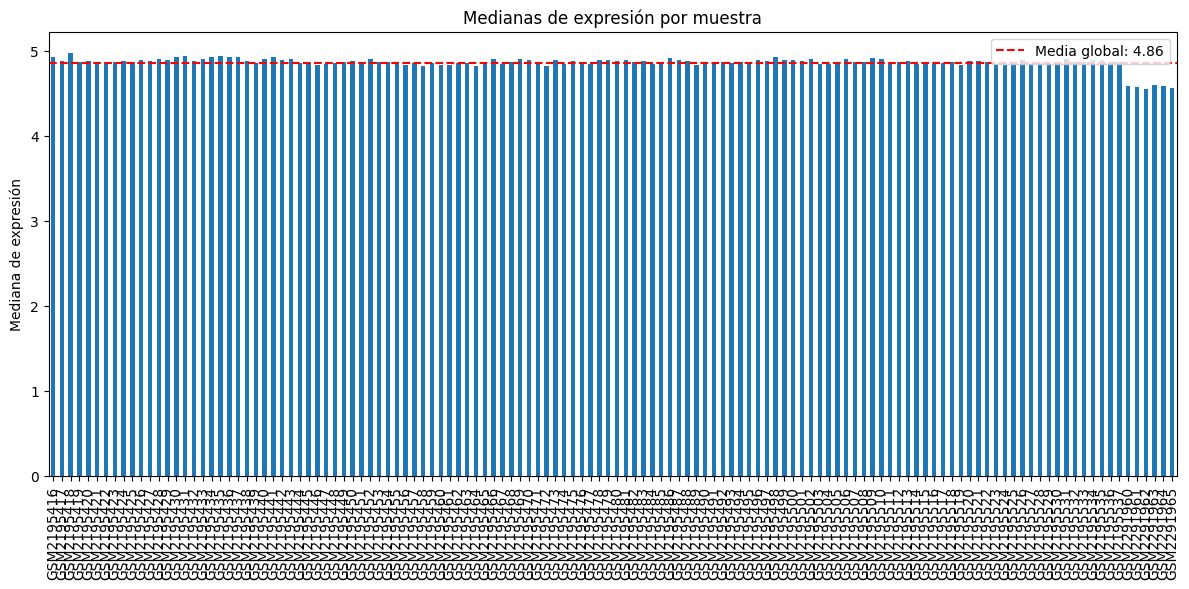

In [ ]:
sample_medians = df_gse_gen.median()

plt.figure(figsize=(12, 6))
sample_medians.plot(kind='bar')
plt.axhline(sample_medians.mean(), color='red', linestyle='--',
           label=f'Media global: {sample_medians.mean():.2f}')
plt.title('Medianas de expresión por muestra')
plt.ylabel('Mediana de expresión')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

Median expression values across samples are aligned, confirming that the dataset is already normalized. This ensures that downstream analyses (limma DEGs, enrichment) are not biased by technical variability

PCA clustering

In [ ]:
for name, gsm in gse.gsms.items():
    print(name, gsm.metadata["title"])

GSM2195416 ['Human_HBV_sample_Hep-0002']
GSM2195417 ['Human_HBV_sample_Hep-0003']
GSM2195418 ['Human_HBV_sample_Hep-0004']
GSM2195419 ['Human_HBV_sample_Hep-0006']
GSM2195420 ['Human_HBV_sample_Hep-0007']
GSM2195421 ['Human_HBV_sample_Hep-0024']
GSM2195422 ['Human_HBV_sample_Hep-0025']
GSM2195423 ['Human_HBV_sample_Hep-0026']
GSM2195424 ['Human_HBV_sample_Hep-0030']
GSM2195425 ['Human_HBV_sample_Hep-0031']
GSM2195426 ['Human_HBV_sample_Hep-0032']
GSM2195427 ['Human_HBV_sample_Hep-0036']
GSM2195428 ['Human_HBV_sample_Hep-0039']
GSM2195429 ['Human_HBV_sample_Hep-0040']
GSM2195430 ['Human_HBV_sample_Hep-0059']
GSM2195431 ['Human_HBV_sample_Hep-0061']
GSM2195432 ['Human_HBV_sample_Hep-0067']
GSM2195433 ['Human_HBV_sample_Hep-0068']
GSM2195434 ['Human_HBV_sample_Hep-0069']
GSM2195435 ['Human_HBV_sample_Hep-0071']
GSM2195436 ['Human_HBV_sample_Hep-0072']
GSM2195437 ['Human_HBV_sample_Hep-0073']
GSM2195438 ['Human_HBV_sample_Hep-0074']
GSM2195439 ['Human_HBV_sample_Hep-0075']
GSM2195440 ['Hum

In [ ]:
sample_labels = {}
for name, gsm in gse.gsms.items():
    title = gsm.metadata['title'][0].lower()
    if 'normal' in title:
        sample_labels[name] = 'control'
    elif 'hbv' in title:
        sample_labels[name] = 'infected'

In [ ]:
labels = pd.Series(sample_labels)

In [ ]:
labels

,0
GSM2195416,infected
GSM2195417,infected
GSM2195418,infected
GSM2195419,infected
GSM2195420,infected
...,...
GSM2291961,control
GSM2291962,control
GSM2291963,control
GSM2291964,control


In [ ]:
labels.value_counts()

,count
infected,122
control,6


In [ ]:
expression_data = df_gse_gen.T

expression_std = StandardScaler().fit_transform(expression_data)

pca = PCA()
expression_2d = pca.fit_transform(expression_std)

expression_pca = pd.DataFrame(expression_2d)
expression_pca.index = expression_data.index
expression_pca.columns = ['PC{}'.format(i+1) for i in expression_pca.columns]

expression_pca['Group'] = [labels[sample] for sample in expression_data.index]

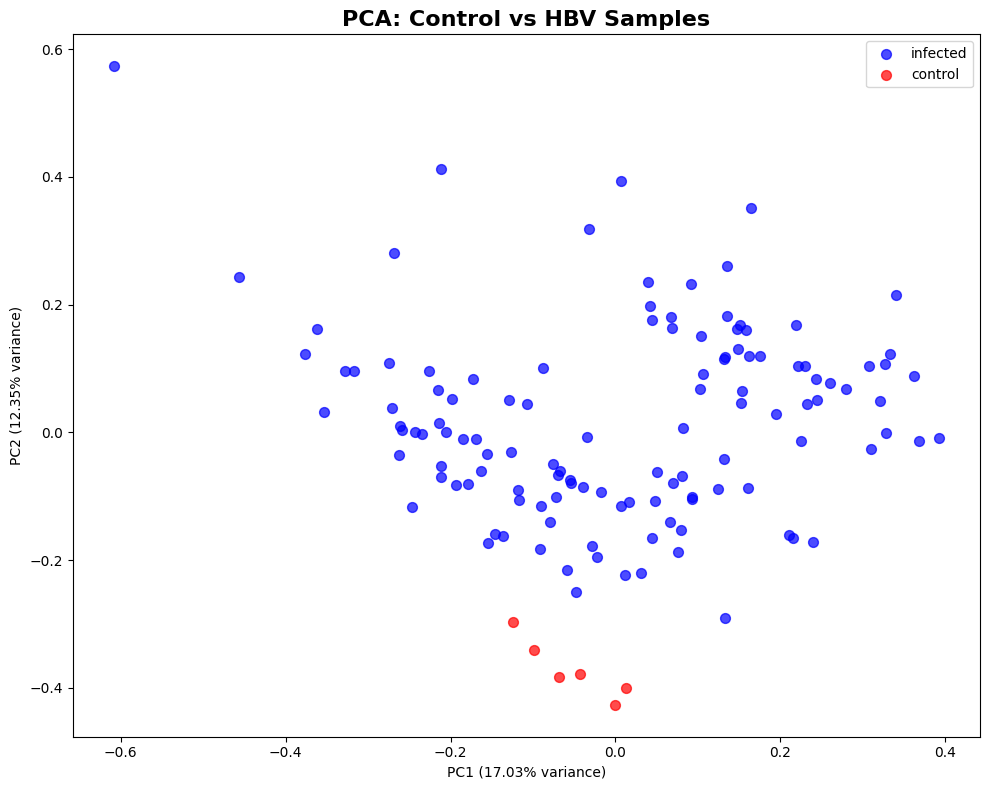

In [ ]:
scale1 = 1.0 / (max(expression_pca['PC1']) - min(expression_pca['PC1']))
scale2 = 1.0 / (max(expression_pca['PC2']) - min(expression_pca['PC2']))

expression_pca['PC1_normalized'] = [i * scale1 for i in expression_pca['PC1']]
expression_pca['PC2_normalized'] = [i * scale2 for i in expression_pca['PC2']]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

groups = expression_pca['Group'].unique()
colors = ['blue', 'red']  # Control, HBV

for group, color in zip(groups, colors):
    group_data = expression_pca[expression_pca['Group'] == group]
    ax.scatter(group_data['PC1_normalized'], group_data['PC2_normalized'],
               label=group, alpha=0.7, s=50, color=color)

ax.set_title('PCA: Control vs HBV Samples', fontsize=16, fontweight='bold')
ax.set_xlabel('PC1 ({}% variance)'.format(round(pca.explained_variance_ratio_[0]*100, 2)))
ax.set_ylabel('PC2 ({}% variance)'.format(round(pca.explained_variance_ratio_[1]*100, 2)))
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("Samples in gene expression", df_gse_gen.columns.tolist())
print("Samples in labels", labels.index.tolist())

# Verificar que coinciden el orden
if list(df_gse_gen.columns) == labels.index.tolist():
    print("Correct")
else:
    print("Mistakes")

Samples in gene expression ['GSM2195416', 'GSM2195417', 'GSM2195418', 'GSM2195419', 'GSM2195420', 'GSM2195421', 'GSM2195422', 'GSM2195423', 'GSM2195424', 'GSM2195425', 'GSM2195426', 'GSM2195427', 'GSM2195428', 'GSM2195429', 'GSM2195430', 'GSM2195431', 'GSM2195432', 'GSM2195433', 'GSM2195434', 'GSM2195435', 'GSM2195436', 'GSM2195437', 'GSM2195438', 'GSM2195439', 'GSM2195440', 'GSM2195441', 'GSM2195442', 'GSM2195443', 'GSM2195444', 'GSM2195445', 'GSM2195446', 'GSM2195447', 'GSM2195448', 'GSM2195449', 'GSM2195450', 'GSM2195451', 'GSM2195452', 'GSM2195453', 'GSM2195454', 'GSM2195455', 'GSM2195456', 'GSM2195457', 'GSM2195458', 'GSM2195459', 'GSM2195460', 'GSM2195461', 'GSM2195462', 'GSM2195463', 'GSM2195464', 'GSM2195465', 'GSM2195466', 'GSM2195467', 'GSM2195468', 'GSM2195469', 'GSM2195470', 'GSM2195471', 'GSM2195472', 'GSM2195473', 'GSM2195474', 'GSM2195475', 'GSM2195476', 'GSM2195477', 'GSM2195478', 'GSM2195479', 'GSM2195480', 'GSM2195481', 'GSM2195482', 'GSM2195483', 'GSM2195484', 'GSM21

Principal Component Analysis (PCA) was performed to assess sample structure. The first two principal components (PC1 = 17%, PC2 = 12%) together explain ~29% of the variance. Control samples cluster tightly, indicating high consistency. HBV-infected samples separate from controls along PC1 and PC2, while also displaying more dispersion, reflecting biological heterogeneity of infection. This supports that the dataset contains a clear HBV effect distinguishable from baseline variation.

In [ ]:
df_gse_gen.to_csv("expression_matrix.csv")

In [ ]:
metadata_df = pd.DataFrame({
    'sample_id': labels.index.tolist(),
    'condition': labels.values
})
metadata_df.to_csv("metadata.csv", index=False)

### d. Differencial Gene Expression (DEGs)

Instead of a simple t-test, I used the limma package in R, which applies empirical Bayes shrinkage and is widely accepted for microarray and RNA-seq analyses.
This provides more robust fold-changes and adjusted p-values.
Compared to my earlier Python analysis, the log2 fold-change values are now spread more widely (around ±3 instead of ±0.6), making it easier to detect meaningful differences

In [ ]:
# Load data using rpy2
ro.r('expr_matrix <- read.csv("expression_matrix.csv", row.names=1)')
ro.r('metadata <- read.csv("metadata.csv")')

expr_matrix_df = pandas2ri.rpy2py(ro.r('expr_matrix'))
metadata_df_r = pandas2ri.rpy2py(ro.r('metadata'))

print("Expression Matrix:")
display(expr_matrix_df.head())
print("\nMetadata:")
display(metadata_df_r.head())

Expression Matrix:


,GSM2195416,GSM2195417,GSM2195418,GSM2195419,GSM2195420,GSM2195421,GSM2195422,GSM2195423,GSM2195424,GSM2195425,...,GSM2195534,GSM2195535,GSM2195536,GSM2195537,GSM2291960,GSM2291961,GSM2291962,GSM2291963,GSM2291964,GSM2291965
A1BG,11.63750,12.160500,12.691400,12.553900,11.871800,11.58390,11.808100,11.504100,11.701300,11.809800,...,12.557400,11.833200,12.528500,12.632300,12.24190,12.322200,12.451700,12.452700,12.481400,12.43490
A1BG-AS1,3.78837,4.939100,4.043060,4.443840,3.905350,3.49460,3.845120,3.583990,3.594870,3.681890,...,4.388870,4.223270,4.410480,4.337600,4.24141,3.819080,3.912930,4.122000,3.885510,3.93615
A1CF,9.69360,9.972655,10.037105,10.184980,9.963775,9.68156,9.984255,9.751525,9.782985,9.907275,...,9.477005,8.625375,10.194825,10.374590,10.78025,10.436875,10.345575,10.521105,10.814650,10.81170
A2M,8.52523,8.200570,7.979665,8.833445,9.003965,8.38389,8.283265,8.443475,8.420625,8.459235,...,8.232885,7.914230,8.668230,8.688415,7.59560,8.044635,7.745155,8.152985,8.262555,8.14561
A2M-AS1,5.29198,5.731150,3.603800,5.671440,4.483800,4.80784,4.841190,4.798840,5.206340,5.244880,...,5.485170,4.371190,5.836250,5.719630,4.30102,4.200840,3.998950,4.192130,4.946260,4.89772



Metadata:


,sample_id,condition
1,GSM2195416,infected
2,GSM2195417,infected
3,GSM2195418,infected
4,GSM2195419,infected
5,GSM2195420,infected


In [ ]:
ro.r('''
library(limma)

conditions <- factor(metadata$condition)
design <- model.matrix(~0 + conditions)
colnames(design) <- levels(conditions)
''')

In [ ]:
ro.r('''
# Linear Model
fit <- lmFit(expr_matrix, design)

# Infected vs control
contrast.matrix <- makeContrasts(infected - control, levels=design)
fit2 <- contrasts.fit(fit, contrast.matrix)
fit2 <- eBayes(fit2)

# Differential Gene Expression
all_results <- topTable(fit2, number=Inf, adjust.method="BH")
''')

In [ ]:
ro.r('''
# Save table of degs
write.csv(all_results, "deg_all.csv")

# Filtering genes of interest
target_genes <- c("RSAD2", "CMPK2", "CH25H", "IRG1", "ACOD1", "PTGS1",
                 "PTGS2", "ALOX5", "ALOX15", "IDO1", "TDO2", "CYP3A4", "CYP2C9")

enzymes_interest <- all_results[rownames(all_results) %in% target_genes, ]
write.csv(enzymes_interest, "enzymes_of_interest.csv")
''')

In [ ]:
deg_all_df = pandas2ri.rpy2py(ro.r('all_results'))
print("Top DEGs:")
display(deg_all_df.head())

enzymes_df = pandas2ri.rpy2py(ro.r('enzymes_interest'))
print(" Genes of interest")
display(enzymes_df)

Top DEGs:


,logFC,AveExpr,t,P.Value,adj.P.Val,B
CTBP1,0.939720,8.371868,17.226061,2.293720e-35,5.394830e-31,69.383874
RBM42,1.563826,7.447858,16.209645,5.155040e-33,6.062327e-29,64.132423
AKT1,1.664231,7.687429,15.192381,1.309996e-30,1.027037e-26,58.749512
MLF2,1.225939,9.106792,14.194431,3.326169e-28,1.955787e-24,53.356573
R3HDM4,1.144105,7.511674,13.892771,1.805950e-27,8.495187e-24,51.706826


 Genes of interest


,logFC,AveExpr,t,P.Value,adj.P.Val,B
PTGS1,0.718243,5.804331,5.671294,8.750304e-08,0.000001,7.456500
PTGS2,0.660456,2.551652,4.970426,2.064965e-06,0.000016,4.413915
ALOX5,0.461880,4.536196,3.788643,2.305859e-04,0.000827,-0.064524
IDO1,0.816957,5.472978,3.446947,7.641329e-04,0.002247,-1.182271
TDO2,-0.547881,8.935032,-3.331394,1.125124e-03,0.003094,-1.540492
CH25H,1.206577,4.204455,3.234410,1.545458e-03,0.004037,-1.833205
IRG1,0.346146,2.631618,3.040009,2.861040e-03,0.006810,-2.397671
CMPK2,1.006037,7.347539,2.967289,3.576787e-03,0.008220,-2.601048
ALOX15,0.314919,2.914454,2.909772,4.255856e-03,0.009514,-2.758865
CYP2C9,-0.171017,10.731717,-1.532685,1.277823e-01,0.177480,-5.684381


In [ ]:
ro.r('''
png("volcano_detailed.png", width=1200, height=800)
plot(all_results$logFC,
     -log10(all_results$adj.P.Val),
     xlab = "log2 Fold Change",
     ylab = "-log10(adjusted p-value)",
     main = "Volcano Plot: HBV infected vs Control",
     pch = 20, col = "gray")

abline(v = c(-1, 1), col = "red", lty = 2)
abline(h = -log10(0.05), col = "blue", lty = 2)

# Show significant genes
sig_genes <- all_results[all_results$adj.P.Val < 0.05 & abs(all_results$logFC) > 1, ]
points(sig_genes$logFC, -log10(sig_genes$adj.P.Val),
       pch = 20, col = "red")

# Show top 10 genes
top_10 <- head(sig_genes[order(sig_genes$adj.P.Val), ], 10)
text(top_10$logFC, -log10(top_10$adj.P.Val),
     labels = rownames(top_10), pos = 3, cex = 0.7, col = "darkred")

dev.off()
''')

2


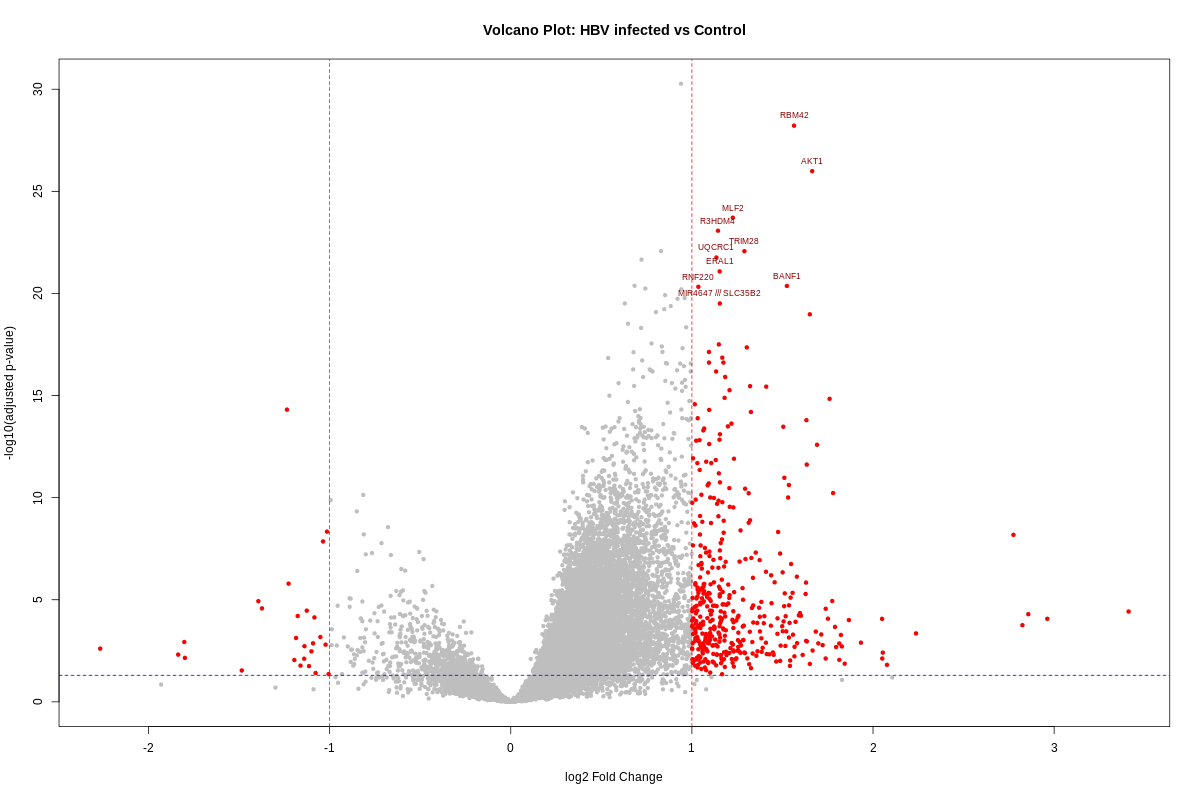

In [ ]:
from IPython.display import Image, display

# Mostrar la imagen guardada
display(Image(filename="volcano_detailed.png"))

### e. Functional Enrichment

Here you had two approaches:

Manual enrichment (ORA — Over-Representation Analysis):
You defined the pathways of interest (Interferon, lipid/nucleotide metabolism, xenobiotics, oxysterol/prostaglandin).
Then I tested whether significantly changed genes are over-represented in those lists using a hypergeometric test.
This is a direct yes/no test for enrichment.


Reactome GSEA (Gene Set Enrichment Analysis):
Instead of cutting at a significance threshold, GSEA takes all genes ranked by fold-change or test statistic and checks if the members of a pathway accumulate toward the top or bottom of the ranking.
This detects coordinated but subtle shifts that single-gene tests may miss.

In [ ]:
ro.r('''

# Manual Enrichment
sig_genes <- rownames(all_results)[all_results$adj.P.Val < 0.05 & abs(all_results$logFC) > 1]
print(paste("Significant genes:", length(sig_genes)))

enrichment_results$Category <- case_when(
  grepl("Interferon|Antiviral", enrichment_results$Pathway) ~ "Interferon / Innate Immune",
  grepl("Lipid|Nucleotide", enrichment_results$Pathway) ~ "Lipid / Nucleotide Metabolism",
  grepl("Xenobiotic", enrichment_results$Pathway) ~ "Xenobiotic Enzymes",
  grepl("Oxysterol|Prostaglandin", enrichment_results$Pathway) ~ "Oxysterol / Prostaglandin",
  TRUE ~ "Other"
)

plot_data <- enrichment_results[enrichment_results$Category != "Other", ]

library(ggplot2)
manual_plot <- ggplot(plot_data,
                      aes(x = Count,
                          y = reorder(Pathway, Count))) +
  geom_point(size = 3, color = "black") +
  facet_grid(Category ~ ., scales = "free_y", space = "free_y") +
  labs(title = "Manual Enrichment",
       x = "Number of significant genes",
       y = "Pathway") +
  theme_bw(base_size = 12) +
  theme(strip.text.y = element_text(face = "bold"),
        axis.text.y = element_text(size = 10))

print(manual_plot)


''')

[1] "Significant genes: 446"


In [ ]:
ro.r('''
ggsave("manual_dotplot.png", manual_plot, width = 12, height = 10, dpi = 300, bg = "white")
''')

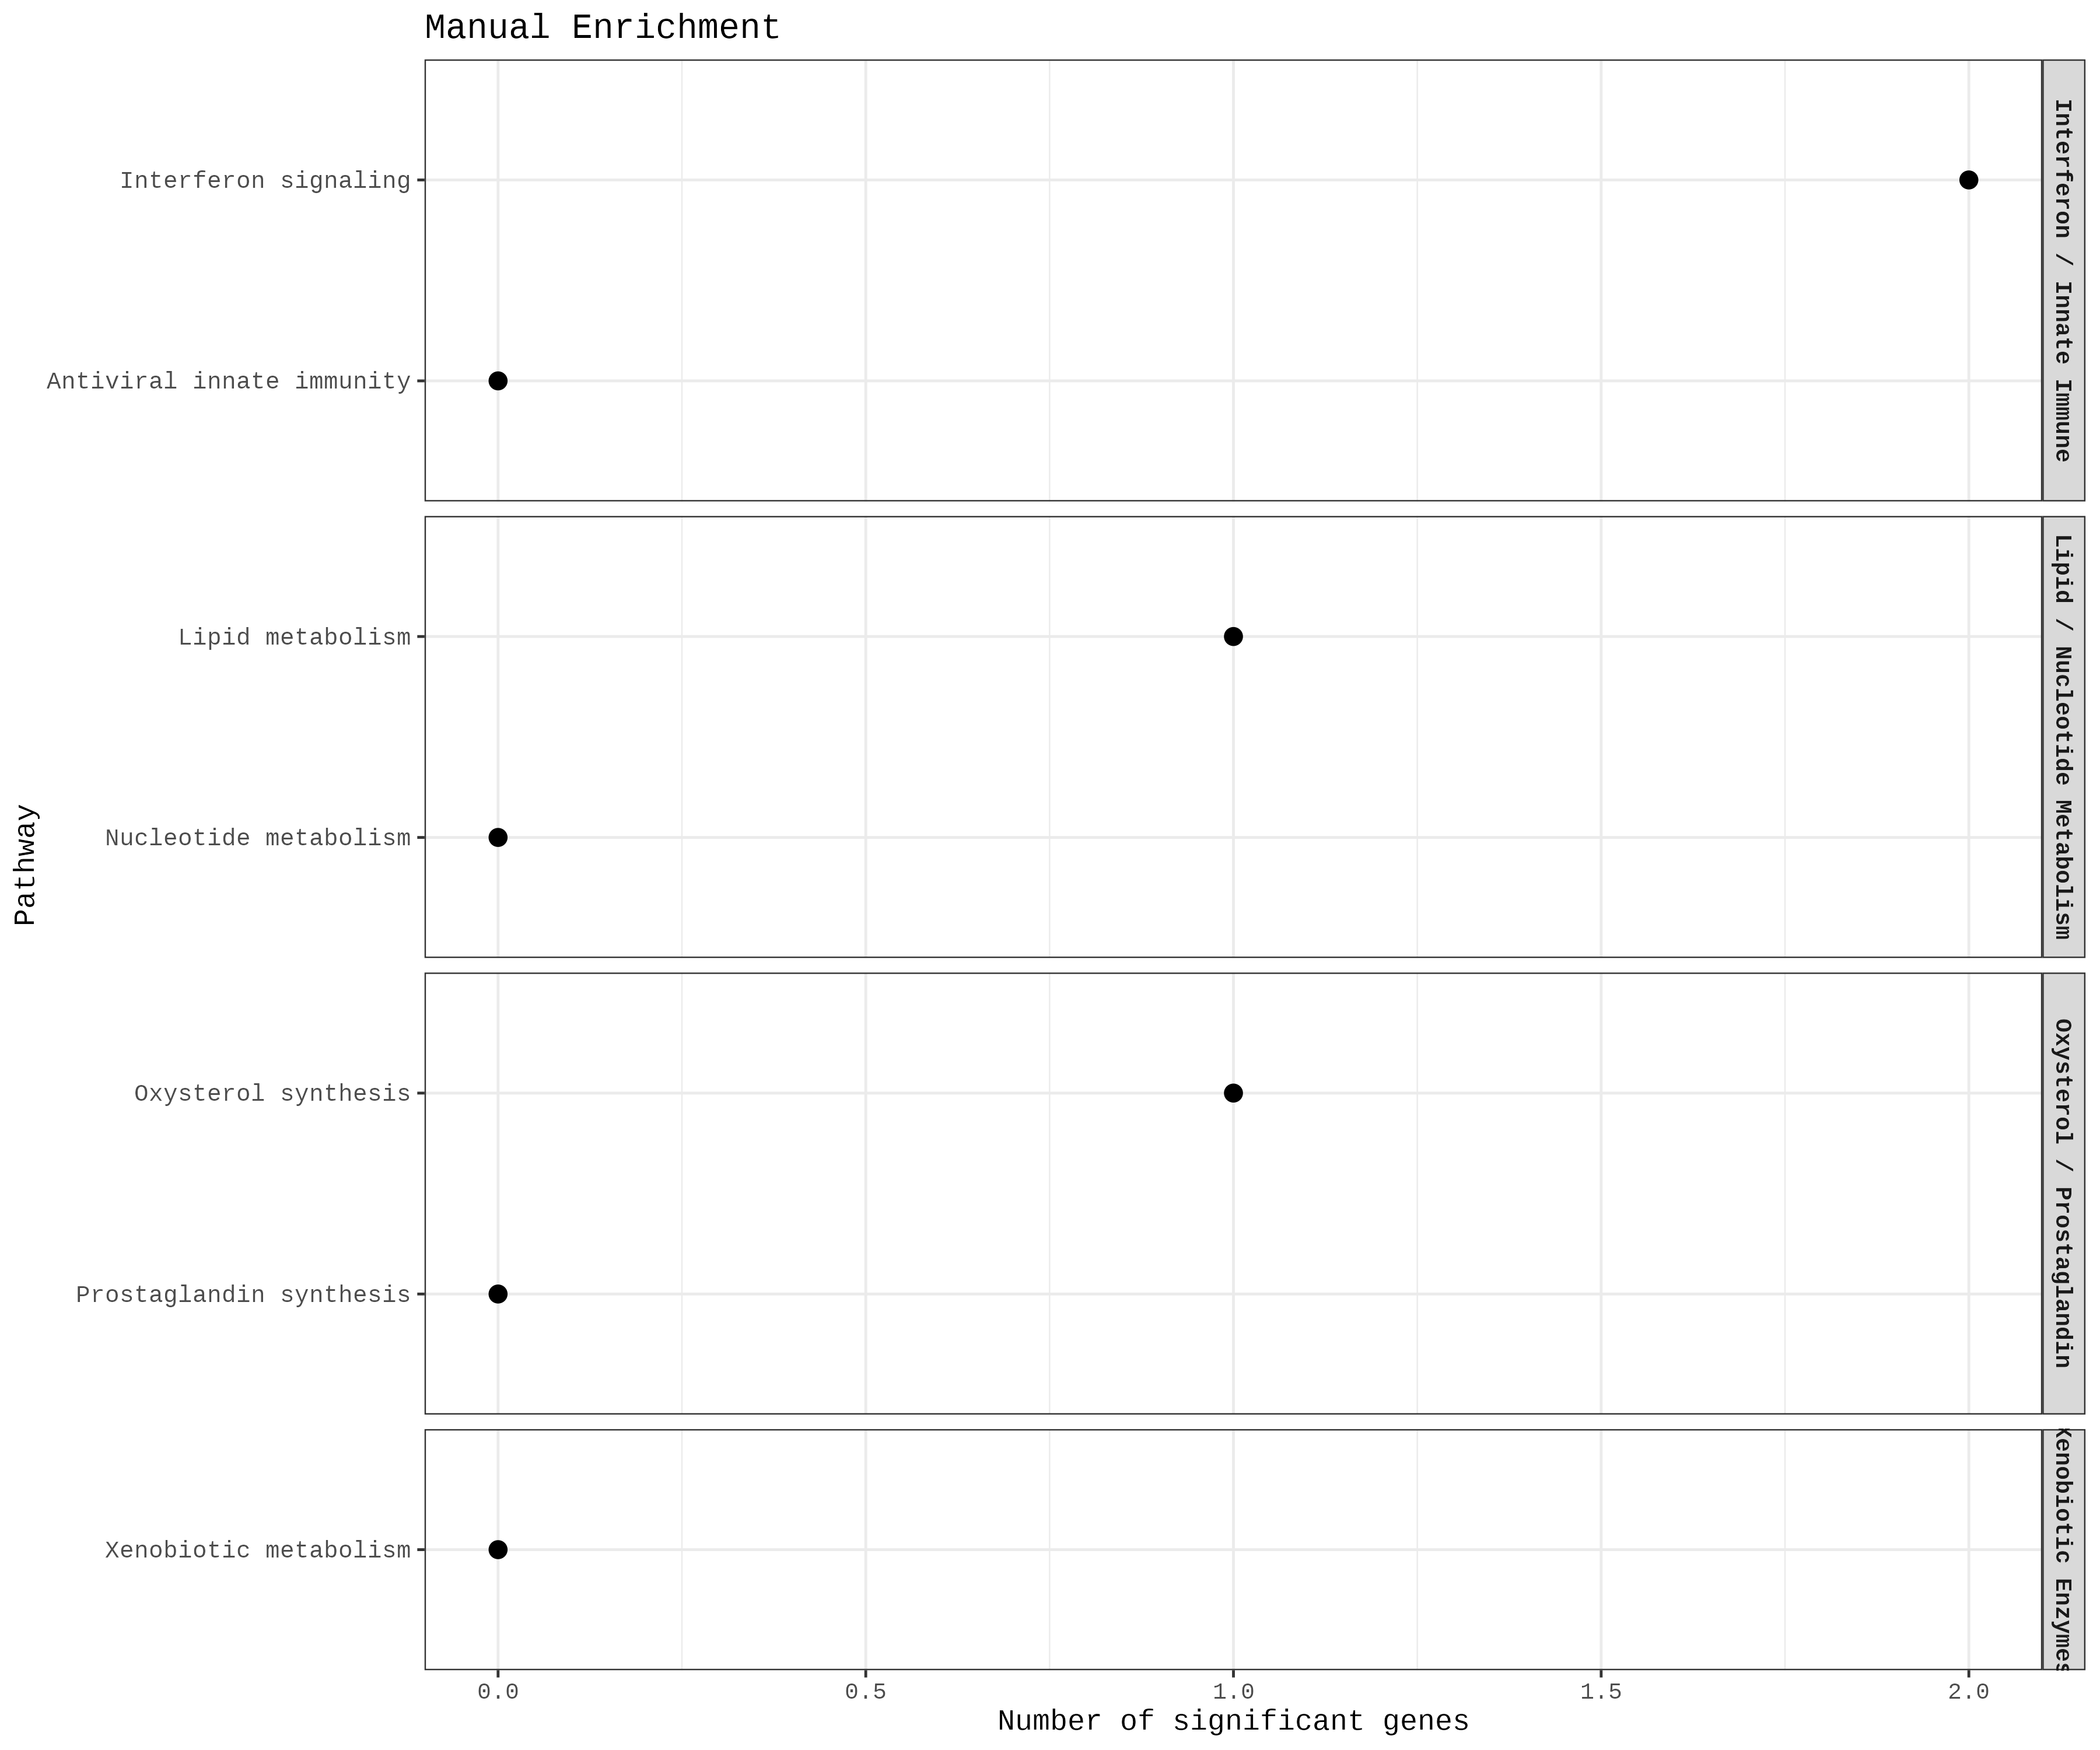

In [ ]:
from IPython.display import Image, display
display(Image(filename="manual_dotplot.png"))


In [ ]:
enrichment_results = pandas2ri.rpy2py(ro.r('enrichment_results'))
display(enrichment_results)

,Pathway,Count,Total_in_pathway,p_value,Genes,adj_p_value,Category
1,Interferon signaling,2,14,0.028083,"MX2, OAS2",0.196582,Interferon / Innate Immune
2,Antiviral innate immunity,0,12,1.000000,,1.000000,Interferon / Innate Immune
3,Lipid metabolism,1,12,0.205300,AGPAT1,0.479033,Lipid / Nucleotide Metabolism
4,Nucleotide metabolism,0,12,1.000000,,1.000000,Lipid / Nucleotide Metabolism
5,Xenobiotic metabolism,0,11,1.000000,,1.000000,Xenobiotic Enzymes
6,Oxysterol synthesis,1,10,0.174267,CH25H,0.479033,Oxysterol / Prostaglandin
7,Prostaglandin synthesis,0,8,1.000000,,1.000000,Oxysterol / Prostaglandin


In [ ]:
ro.r('''
library(dplyr)
library(ggplot2)

classify_pathway <- function(description) {
  desc_lower <- tolower(description)

  if (grepl("interferon|antiviral|immune|defense|virus|response", desc_lower)) {
    return("Interferon / Innate Immune")
  } else if (grepl("lipid|fatty|cholesterol|steroid|bile|nucleotide|purine|pyrimidine|dna|rna", desc_lower)) {
    return("Lipid / Nucleotide Metabolism")
  } else if (grepl("xenobiotic|drug|detox|cytochrome", desc_lower)) {
    return("Xenobiotic Enzymes")
  } else if (grepl("oxysterol|prostaglandin", desc_lower)) {
    return("Oxysterol / Prostaglandin")
  } else {
    return("Other")
  }
}

gsea_res$Category <- sapply(gsea_res$Description, classify_pathway)

highlight_categories <- c(
  "Interferon / Innate Immune",
  "Lipid / Nucleotide Metabolism",
  "Xenobiotic Enzymes",
  "Oxysterol / Prostaglandin"
)

plot_data <- gsea_res %>%
  filter(Category %in% highlight_categories) %>%
  arrange(NES)  # ordenar por NES para el dotplot

# Dot plot
dotplot <- ggplot(plot_data,
                      aes(x = setSize,             # similar a Count
                      y = reorder(Description, setSize))) +
  geom_point(size = 3, color = "black") +
  facet_grid(Category ~ ., scales = "free_y", space = "free_y") +
  labs(title = "GSEA Reactome Enrichment",
       x = "Number of genes in pathway",
       y = "Pathway") +
  theme_bw(base_size = 12) +
  theme(strip.text.y = element_text(face = "bold"),
        axis.text.y = element_text(size = 10))

highlighted_genes <- plot_data[, c("Description", "Category", "setSize", "core_enrichment")]
print(highlighted_genes)
''')

                                                      Description
R-HSA-9855142            Cellular responses to mechanical stimuli
R-HSA-76005          Response to elevated platelet cytosolic Ca2+
R-HSA-877300                           Interferon gamma signaling
R-HSA-5260271                           Diseases of Immune System
R-HSA-162658  Golgi Cisternae Pericentriolar Stack Reorganization
                                   Category setSize
R-HSA-9855142    Interferon / Innate Immune     102
R-HSA-76005      Interferon / Innate Immune     124
R-HSA-877300     Interferon / Innate Immune      88
R-HSA-5260271    Interferon / Innate Immune      32
R-HSA-162658  Lipid / Nucleotide Metabolism      14
                                                                                                                                                                                                                                                                                                    

In [ ]:
ro.r('''
ggsave("dotplot.png", dotplot, width = 14, height = 12, dpi = 300, bg = "white")
''')

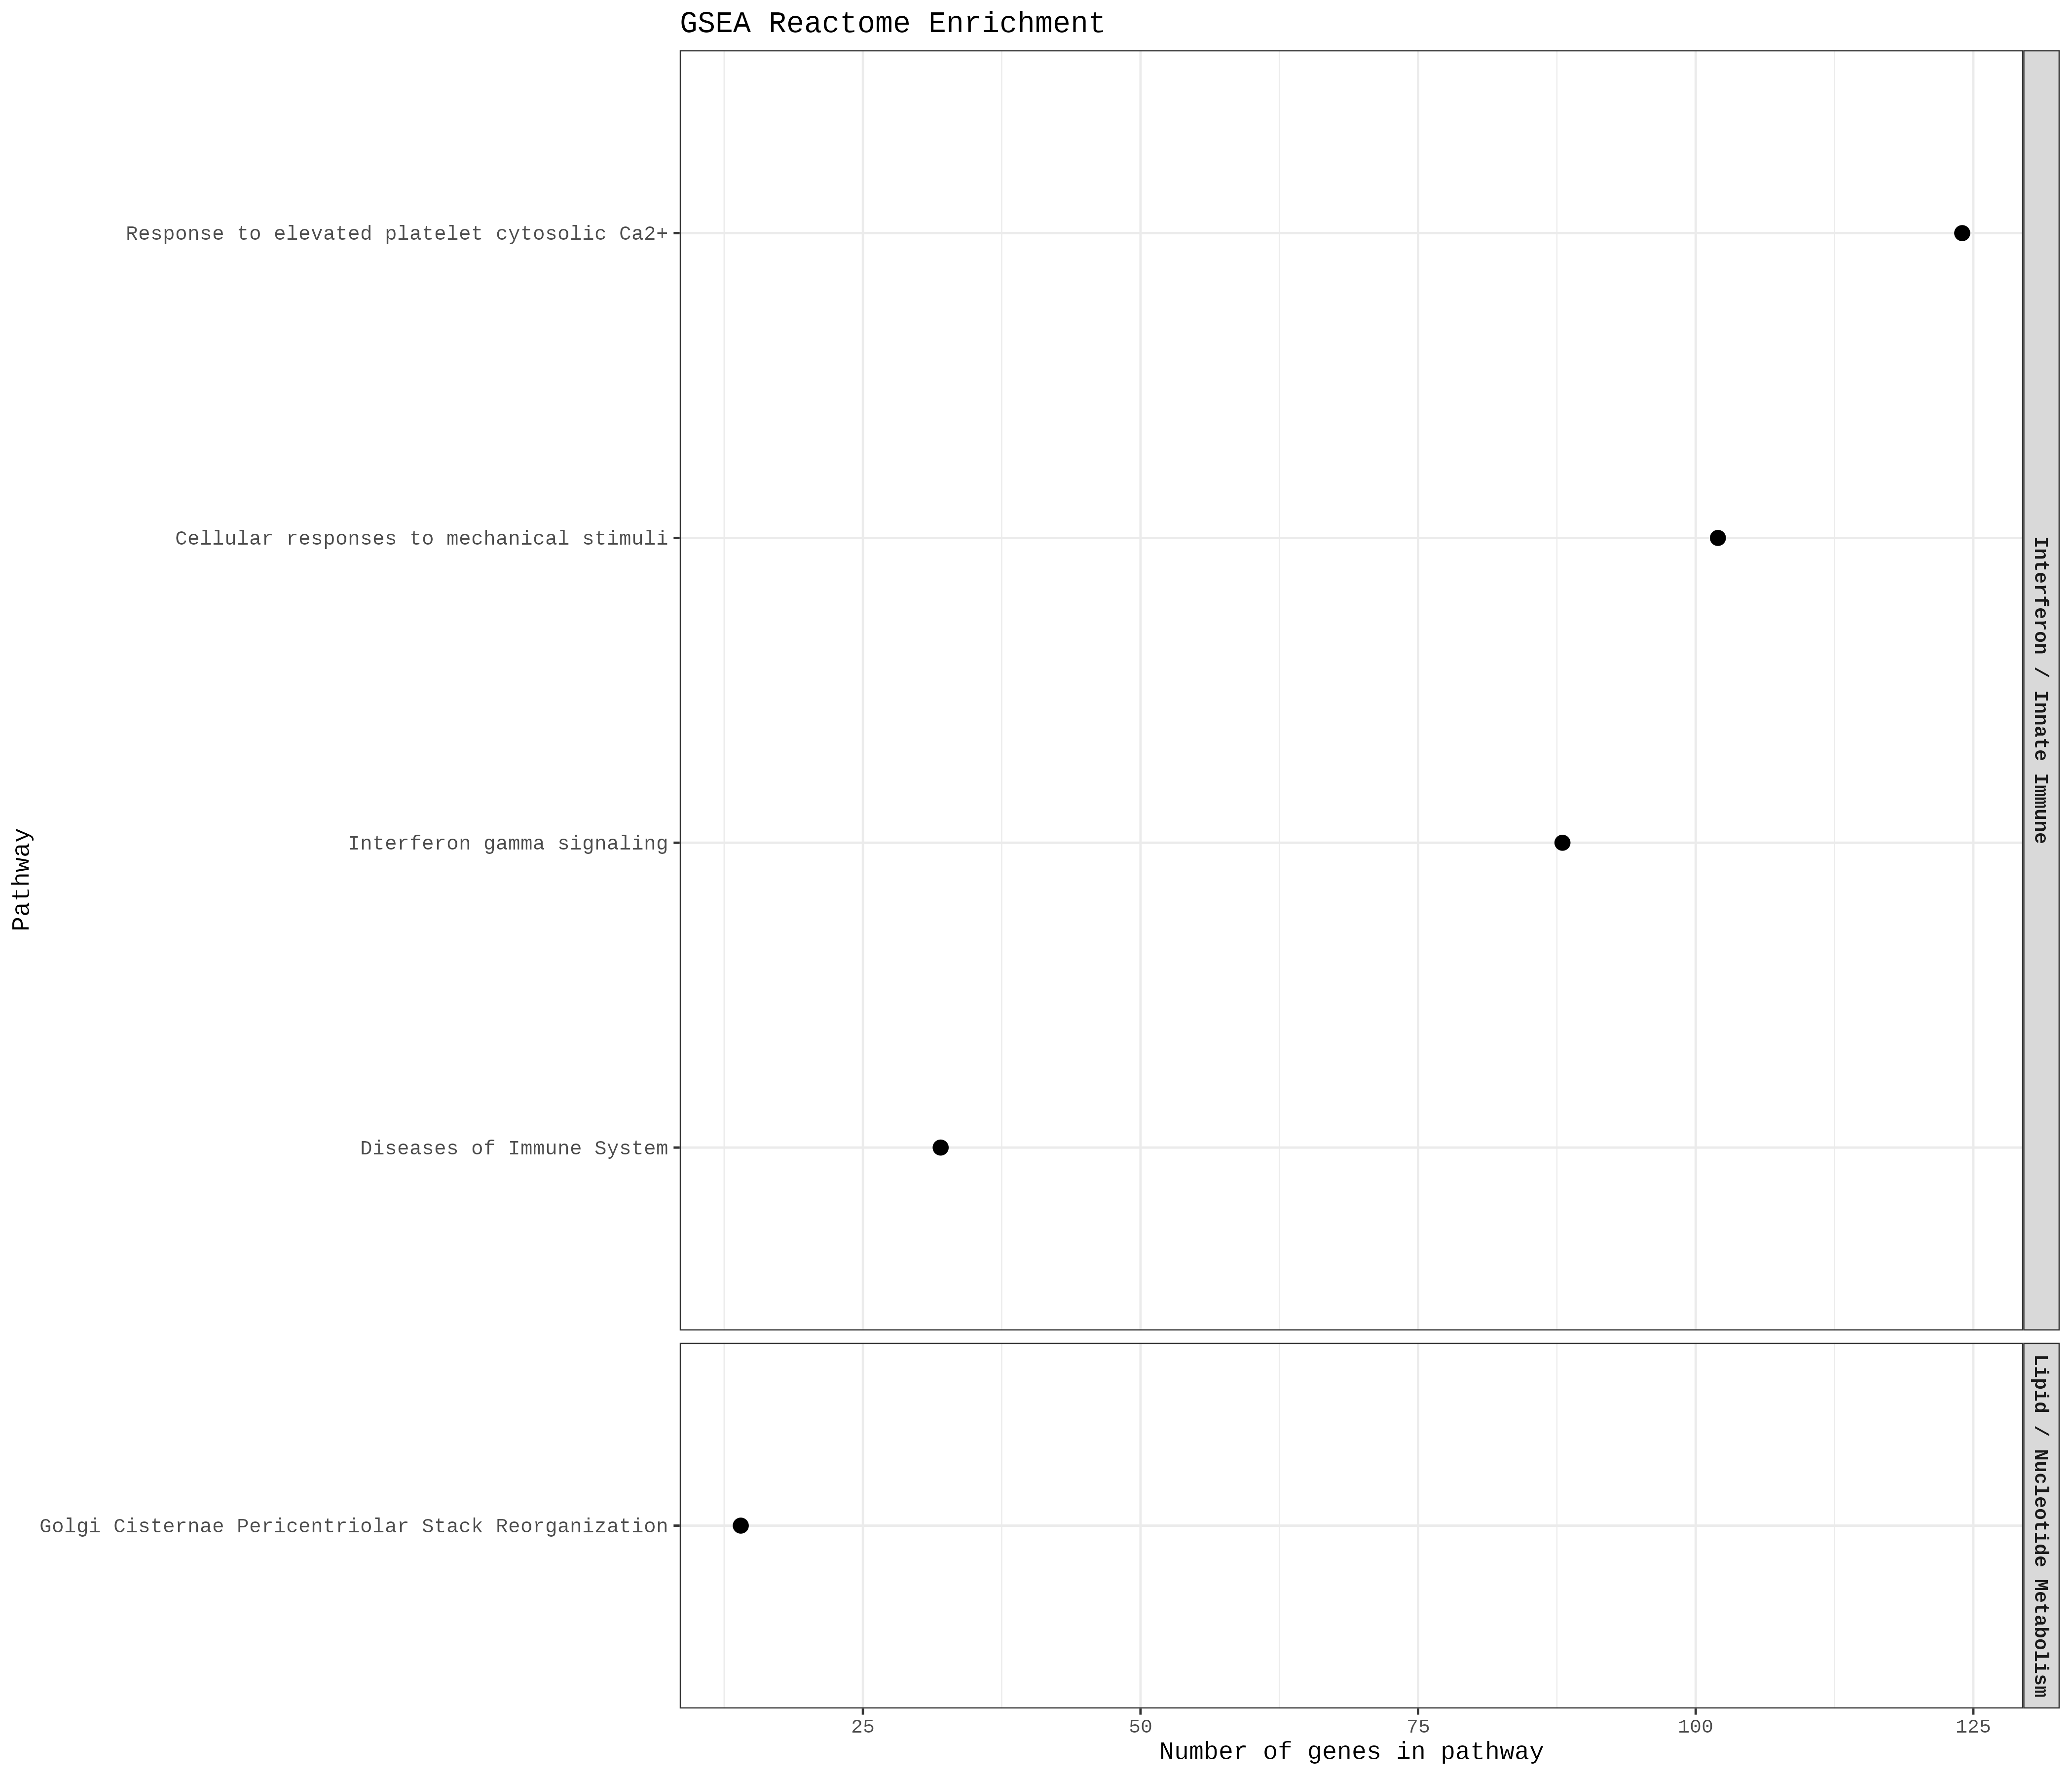

In [ ]:
from IPython.display import Image, display
display(Image(filename="dotplot.png"))